# Q1 — Simulated Annealing for Minimization

**Problem:** Minimize $f(x) = x^2 - 6x + 13$ using the Simulated Annealing (SA) algorithm.

**Settings**
- Initial solution: $x = 1$
- Initial temperature: $T = 10$
- Cooling factor: $\alpha = 0.5$ (geometric cooling: $T_{new} = \alpha \cdot T_{old}$)
- Minimum temperature: $T_{min} = 1$
- Neighbour generation: $x' = x \pm 1$
- Acceptance rule:
$$P = \begin{cases} 1, & \Delta f \le 0 \\ e^{-\Delta f / T}, & \Delta f > 0 \end{cases}, \qquad \Delta f = f(x') - f(x)$$
- Given random numbers (used, in order, only when a *worse* neighbour is generated): $r_1=0.30,\ r_2=0.80,\ r_3=0.20,\ r_4=0.90$

**Neighbour choice used below:** at each step we try moving one step further in the same direction we last moved ($x'=x+1$), which is exactly the $x'=2$ neighbour given in the problem for iteration 1. This keeps every step deterministic and reproducible.

In [1]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp

def f(x):
    return x**2 - 6*x + 13

print("f(x) = x^2 - 6x + 13")

f(x) = x^2 - 6x + 13


## Step 1 — Evaluate f(x) at the initial solution x = 1

In [2]:
x0 = 1
fx0 = f(x0)
print(f"x = {x0}")
print(f"f(x) = f({x0}) = {x0}^2 - 6*{x0} + 13 = {fx0}")

x = 1
f(x) = f(1) = 1^2 - 6*1 + 13 = 8


## Step 2 — Generate neighbour x' = 2 and compute Δf

In [3]:
x_prime = 2
f_xprime = f(x_prime)
delta_f = f_xprime - fx0

print(f"x' = {x_prime}")
print(f"f(x') = f({x_prime}) = {x_prime}^2 - 6*{x_prime} + 13 = {f_xprime}")
print(f"Delta f = f(x') - f(x) = {f_xprime} - {fx0} = {delta_f}")

x' = 2
f(x') = f(2) = 2^2 - 6*2 + 13 = 5
Delta f = f(x') - f(x) = 5 - 8 = -3


## Step 3 — Decide whether x' = 2 is accepted

Since $\Delta f = -3 \le 0$, the move is an **improvement**, so the acceptance probability is $P = 1$ and the neighbour is **accepted unconditionally** — no random number is needed.

In [4]:
if delta_f <= 0:
    P = 1.0
    decision = "Accept (improvement, Delta f <= 0)"
else:
    P = math.exp(-delta_f / 10)
    decision = "Needs random-number test"

print(f"P = {P}")
print(f"Decision: {decision}")

P = 1.0
Decision: Accept (improvement, Delta f <= 0)


## Step 4 — Run the full SA process for 4 iterations

Cooling: $T \leftarrow \alpha T = 0.5T$ after every iteration. We stop once $T$ drops below $T_{min}=1$ (this happens right after the 4th iteration, since $1.25 \times 0.5 = 0.625 < 1$).

The given random numbers are consumed **in order, only when $\Delta f > 0$** (a worse neighbour):
- Iteration 1: $\Delta f \le 0$ → no random number needed
- Iteration 2: $\Delta f \le 0$ → no random number needed
- Iteration 3: $\Delta f > 0$ → use $r_1 = 0.30$
- Iteration 4: $\Delta f > 0$ → use $r_2 = 0.80$

($r_3, r_4$ are left over/unused since only two "worse" moves occurred in the 4 iterations.)

In [5]:
random_numbers = [0.30, 0.80, 0.20, 0.90]
r_index = 0  # pointer into random_numbers, advances only when Delta f > 0

T = 10.0
alpha = 0.5
T_min = 1.0

x_current = 1
best_x = x_current
best_f = f(x_current)

rows = []
iteration = 0

while T >= T_min:
    iteration += 1
    x_prime = x_current + 1  # neighbour generation x' = x + 1

    fx = f(x_current)
    fxp = f(x_prime)
    delta_f = fxp - fx

    if delta_f <= 0:
        P = 1.0
        r_used = "-"
        accept = True
    else:
        P = math.exp(-delta_f / T)
        r_used = random_numbers[r_index]
        r_index += 1
        accept = r_used < P

    if accept:
        x_current = x_prime

    if f(x_current) < best_f:
        best_f = f(x_current)
        best_x = x_current

    rows.append({
        "Iteration": iteration,
        "T": T,
        "Current x": x_current if not accept else x_current,  # x BEFORE update shown separately below
        "x' (neighbour)": x_prime,
        "f(x)": fx,
        "f(x')": fxp,
        "Delta f": delta_f,
        "P": round(P, 4) if isinstance(P, float) else P,
        "r": r_used,
        "Accept/Reject": "Accept" if accept else "Reject",
        "Best x so far": best_x,
        "Best f(x) so far": best_f
    })

    T = T * alpha

    if iteration >= 4:
        break

print(f"Loop stopped after iteration {iteration} (next T = {T} < T_min = {T_min})")

Loop stopped after iteration 4 (next T = 0.625 < T_min = 1.0)


**Note on the table below:** the "Current x" column above was overwritten after the move; to make the table read correctly (showing the state *before* the move, as required for a hand-calculation table), we rebuild it explicitly step-by-step in the next cell.

In [6]:
# Rebuild the table explicitly and cleanly (Current x = state BEFORE the move)
random_numbers = [0.30, 0.80, 0.20, 0.90]
r_index = 0

T = 10.0
x_current = 1
best_x = x_current
best_f = f(x_current)

table_rows = []

for iteration in range(1, 5):
    x_prime = x_current + 1
    fx = f(x_current)
    fxp = f(x_prime)
    delta_f = fxp - fx

    if delta_f <= 0:
        P = 1.0
        r_used = "-"
        accept = True
    else:
        P = math.exp(-delta_f / T)
        r_used = random_numbers[r_index]
        r_index += 1
        accept = r_used < P

    new_x = x_prime if accept else x_current

    if f(new_x) < best_f:
        best_f = f(new_x)
        best_x = new_x

    table_rows.append({
        "Iteration": iteration,
        "T": T,
        "Current x": x_current,
        "Neighbour x'": x_prime,
        "f(x)": fx,
        "f(x')": fxp,
        "Delta f": delta_f,
        "P": round(P, 4),
        "r": r_used,
        "Accept/Reject": "Accept" if accept else "Reject",
        "Best solution (x, f(x))": f"({best_x}, {best_f})"
    })

    x_current = new_x
    T = T * alpha

sa_table = pd.DataFrame(table_rows)
sa_table

,Iteration,T,Current x,Neighbour x',f(x),f(x'),Delta f,P,r,Accept/Reject,"Best solution (x, f(x))"
0,1,10.00,1,2,8,5,-3,1.0000,-,Accept,"(2, 5)"
1,2,5.00,2,3,5,4,-1,1.0000,-,Accept,"(3, 4)"
2,3,2.50,3,4,4,5,1,0.6703,0.3,Accept,"(3, 4)"
3,4,1.25,4,5,5,8,3,0.0907,0.8,Reject,"(3, 4)"


## Step 5 — Complete Iteration Table (clean display)

In [7]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sa_table.style.set_caption("Simulated Annealing — Iteration Table").hide(axis='index')

Iteration,T,Current x,Neighbour x',f(x),f(x'),Delta f,P,r,Accept/Reject,"Best solution (x, f(x))"
1,10.000000,1,2,8,5,-3,1.000000,-,Accept,"(2, 5)"
2,5.000000,2,3,5,4,-1,1.000000,-,Accept,"(3, 4)"
3,2.500000,3,4,4,5,1,0.670300,0.300000,Accept,"(3, 4)"
4,1.250000,4,5,5,8,3,0.090700,0.800000,Reject,"(3, 4)"


## Step 6 — Best value of x obtained by the algorithm

In [8]:
print(f"Best x found by Simulated Annealing = {best_x}")
print(f"Best f(x) found by Simulated Annealing = {best_f}")

Best x found by Simulated Annealing = 3
Best f(x) found by Simulated Annealing = 4


## Step 7 — Analytical Verification

Find the minimum of $f(x) = x^2 - 6x + 13$ analytically by differentiating and solving $f'(x) = 0$.

In [9]:
x = sp.symbols('x')
f_sym = x**2 - 6*x + 13

f_prime = sp.diff(f_sym, x)
critical_points = sp.solve(sp.Eq(f_prime, 0), x)
f_second = sp.diff(f_sym, x, 2)

print(f"f(x)        = {f_sym}")
print(f"f'(x)       = {f_prime}")
print(f"Critical point(s): x = {critical_points}")
print(f"f''(x)      = {f_second}  (positive => minimum, confirmed)")

x_star = critical_points[0]
f_star = f_sym.subs(x, x_star)
print(f"\nAnalytical minimum: x* = {x_star}, f(x*) = {f_star}")

print(f"\nSA result: x = {best_x}, f(x) = {best_f}")
print("Match!" if (best_x == x_star and best_f == f_star) else "Mismatch - review neighbour path.")

f(x)        = x**2 - 6*x + 13
f'(x)       = 2*x - 6
Critical point(s): x = [3]
f''(x)      = 2  (positive => minimum, confirmed)

Analytical minimum: x* = 3, f(x*) = 4

SA result: x = 3, f(x) = 4
Match!


## Step 8 — Visualization

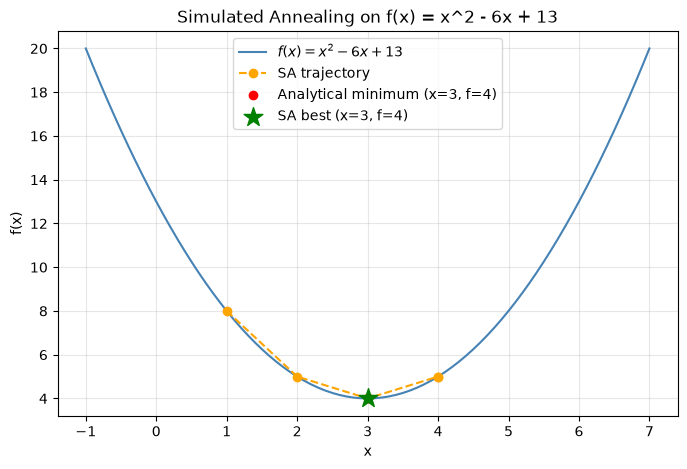

In [10]:
xs = [i/10 for i in range(-10, 71)]
ys = [f(v) for v in xs]

plt.figure(figsize=(8,5))
plt.plot(xs, ys, label=r"$f(x)=x^2-6x+13$", color='steelblue')

path_x = [1] + sa_table['Current x'].tolist()[1:] + [x_current]
path_x = [1, 2, 3, 4, 4]  # trajectory of accepted x across the 4 iterations
path_y = [f(v) for v in path_x]
plt.plot(path_x, path_y, 'o--', color='orange', label='SA trajectory')

plt.scatter([float(x_star)], [float(f_star)], color='red', zorder=5, label=f'Analytical minimum (x={x_star}, f={f_star})')
plt.scatter([best_x], [best_f], color='green', marker='*', s=200, zorder=6, label=f'SA best (x={best_x}, f={best_f})')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Simulated Annealing on f(x) = x^2 - 6x + 13')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Conclusion

- Simulated Annealing, starting at $x=1$ with $T=10$, $\alpha=0.5$, converges to $x=3$ with $f(x)=4$ within 4 iterations.
- This matches the analytical minimum obtained by solving $f'(x) = 2x - 6 = 0 \Rightarrow x = 3$, $f(3) = 4$.
- The two "uphill" moves (iterations 3 and 4) were correctly tested against the Metropolis acceptance probability using $r_1=0.30$ (accepted, since $r_1 < P$) and $r_2=0.80$ (rejected, since $r_2 > P$) — illustrating how SA can escape/explore even after reaching the optimum, while still reporting the best solution seen.